In [86]:
import pandas as pd
df = pd.read_csv("../data/TelcoCustomerChurn.csv")
print(df.shape)

(7043, 21)


In [91]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/TelcoCustomerChurn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [92]:
print("Shape:", df.shape)
print("DataFrame:")
# print(df)
df.info()

Shape: (7043, 21)
DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 n

In [93]:
# print("Missing values:\n", df.isnull().sum())
print("Missing values:\n", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customerIDs:", df["customerID"].duplicated().sum())


Missing values:
 0
Duplicate rows: 0
Duplicate customerIDs: 0


In [94]:
# Total 11 rows where TotalCharges is blank. Tenure is 0 for all these rows. So, we can replace blank TotalCharges with 0.
blank = df["TotalCharges"].str.strip() == ""
# print("Blank TotalCharges rows:", blank)
print("Blank TotalCharges rows:", blank.sum())
print(df.loc[blank, ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

Blank TotalCharges rows: 11
      tenure  MonthlyCharges TotalCharges Churn
488        0           52.55                 No
753        0           20.25                 No
936        0           80.85                 No
1082       0           25.75                 No
1340       0           56.05                 No
3331       0           19.85                 No
3826       0           25.35                 No
4380       0           20.00                 No
5218       0           19.70                 No
6670       0           73.35                 No
6754       0           61.90                 No


In [95]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
# print(df["TotalCharges"])
print(df["TotalCharges"].dtype, "| nulls:", df["TotalCharges"].isnull().sum())

float64 | nulls: 0


In [96]:
# Drop customerID column and map Churn column to binary values
df = df.drop(columns=["customerID"])
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [97]:
target = "Churn"
numerical = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
categorical = [c for c in df.columns if c not in numerical + [target]]

print("Numerical:", numerical)
print("Categorical:", len(categorical), "→", categorical)
# Checking if there are any missing values or scrape values in the numerical columns like negative values, etc.
df[numerical].describe().round(2)

Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: 15 → ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76,2279.73
std,0.37,24.56,30.09,2266.79
min,0.00,0.00,18.25,0.00
25%,0.00,9.00,35.50,398.55
50%,0.00,29.00,70.35,1394.55
75%,0.00,55.00,89.85,3786.60
max,1.00,72.00,118.75,8684.80


In [98]:
# Target variable analysis. 0 Means No Churn and 1 Means Churn.
print(df[target].value_counts())
print(df[target].value_counts(normalize=True).round(4) * 100)

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [99]:
# Train/Test split (70:30)
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train churn %:", round(y_train.mean() * 100, 2))
print("Test churn %:", round(y_test.mean() * 100, 2))

Train: (4930, 19) | Test: (2113, 19)
Train churn %: 26.53
Test churn %: 26.55


In [100]:
# Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Train encoded:", X_train_encoded.shape)
print("Test encoded:", X_test_encoded.shape)
print("Total features after encoding:", len(preprocessor.get_feature_names_out()))

Train encoded: (4930, 45)
Test encoded: (2113, 45)
Total features after encoding: 45


In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Earlier churn column was mapped to 0/1. Now, we want to see the churn as Yes/No. So, we create a new column ChurnLabel for that.
# eda is a copy of the original dataframe df, with an additional column "ChurnLabel" that maps the binary churn values (0/1) 
# to categorical labels ("No"/"Yes") for better visualization in plots.
eda = df.copy()
eda["ChurnLabel"] = eda["Churn"].map({1: "Yes", 0: "No"})


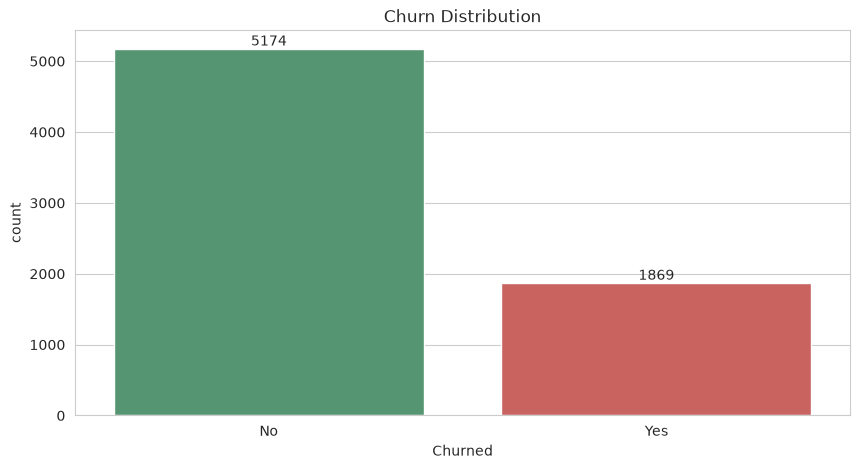

ChurnLabel
No     73.5
Yes    26.5
Name: proportion, dtype: float64


In [102]:
ax = sns.countplot(data=eda, x="ChurnLabel", hue="ChurnLabel",
                   palette=["#4C9F70", "#D9534F"], legend=False)
for c in ax.containers:
    ax.bar_label(c)
plt.title("Churn Distribution")
plt.xlabel("Churned")
plt.show()

print(eda["ChurnLabel"].value_counts(normalize=True).round(3) * 100)

# 26.5% of customers have churned, while 73.5% have not chrned.

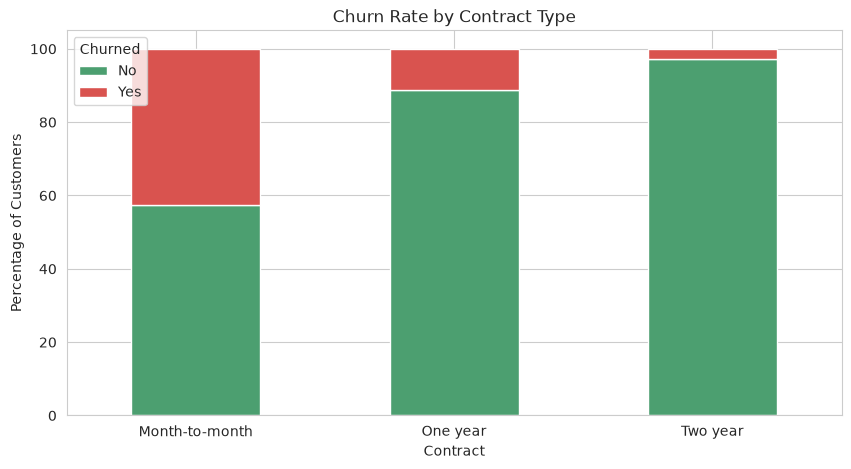

ChurnLabel        No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


In [103]:
# contract type vs churn. This is a stacked bar chart showing the churn rate for each contract type. The x-axis represents the contract types, and the y-axis represents the percentage of customers. The bars are stacked to show the percentage of customers who have churned (in red) versus those who have not churned (in green) for each contract type.

ct = pd.crosstab(eda["Contract"], eda["ChurnLabel"], normalize="index") * 100 # Create a crosstab with normalized values
ct.plot(kind="bar", stacked=True, color=["#4C9F70", "#D9534F"]) # Plot the stacked bar chart
plt.title("Churn Rate by Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0) # x-axis labels should be horizontal for better readability
plt.legend(title="Churned")
plt.show()

# print the churn rate for each contract type rounded to 1 decimal place
print(ct.round(1))

# Month to month contract has hightest chrun rate of approx 43%.
# Business need to take action to reduce churn for month to month contract customers.

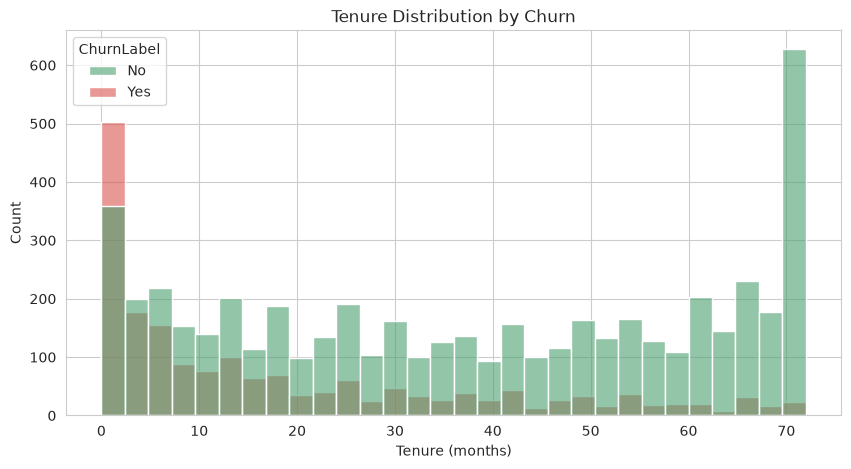

            mean  median
ChurnLabel              
No          37.6    38.0
Yes         18.0    10.0


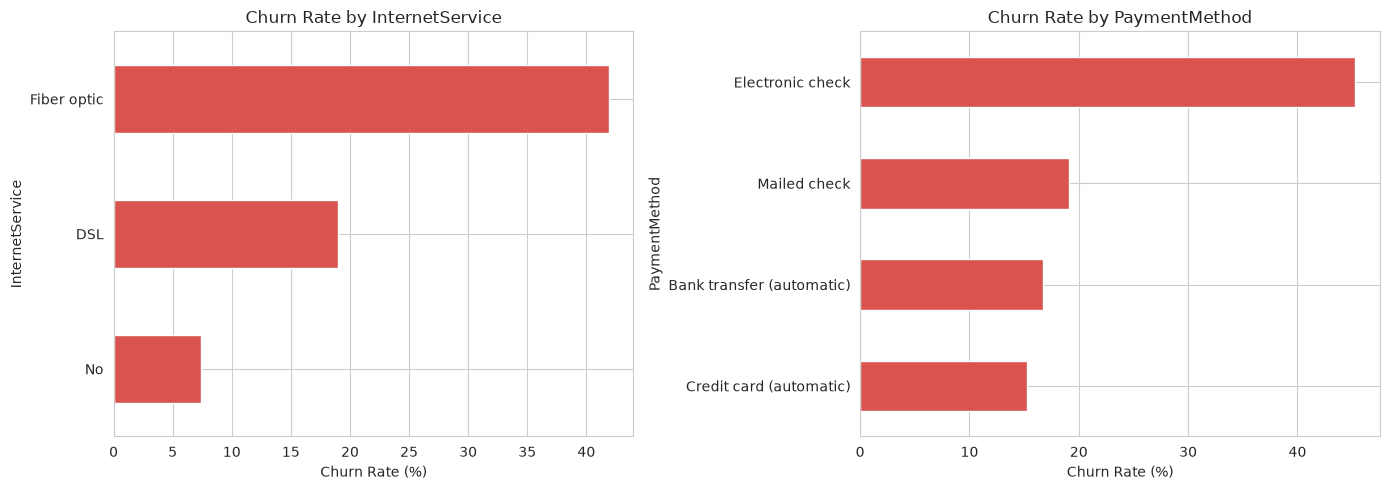

In [104]:
# tenure distribution by churn.
# histogram showing the distribution of tenure (in months) for customers who have churned versus those who have not churned. 
# The x-axis represents the tenure in months, and the y-axis represents the count of customers. 
# The histogram is color-coded to differentiate between churned and non-churned customers.
# Red - churned customers, Green -non-churned customers.

sns.histplot(data=eda, x="tenure", hue="ChurnLabel", bins=30,
             palette=["#4C9F70", "#D9534F"], alpha=0.6)
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (months)")
plt.show()

# Print the mean and median tenure for each churn category
print(eda.groupby("ChurnLabel")["tenure"].agg(["mean", "median"]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ["InternetService", "PaymentMethod"]):
    rate = eda.groupby(col)["Churn"].mean().sort_values() * 100
    rate.plot(kind="barh", ax=ax, color="#D9534F")
    ax.set_title(f"Churn Rate by {col}")
    ax.set_xlabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

# 10 months is the average tenure for churned customer.
# Business need to take action to reduce churn for customers with shorter tenure.

# Internet Service - Fiber optic has highest churn rate of approx 45%. Business need to take action to reduce churn for customers with fiber optic internet service.
# Payment Method - Electronic check has highest churn rate of approx 44%. Business need to take action to reduce churn for customers using electronic check payment method.


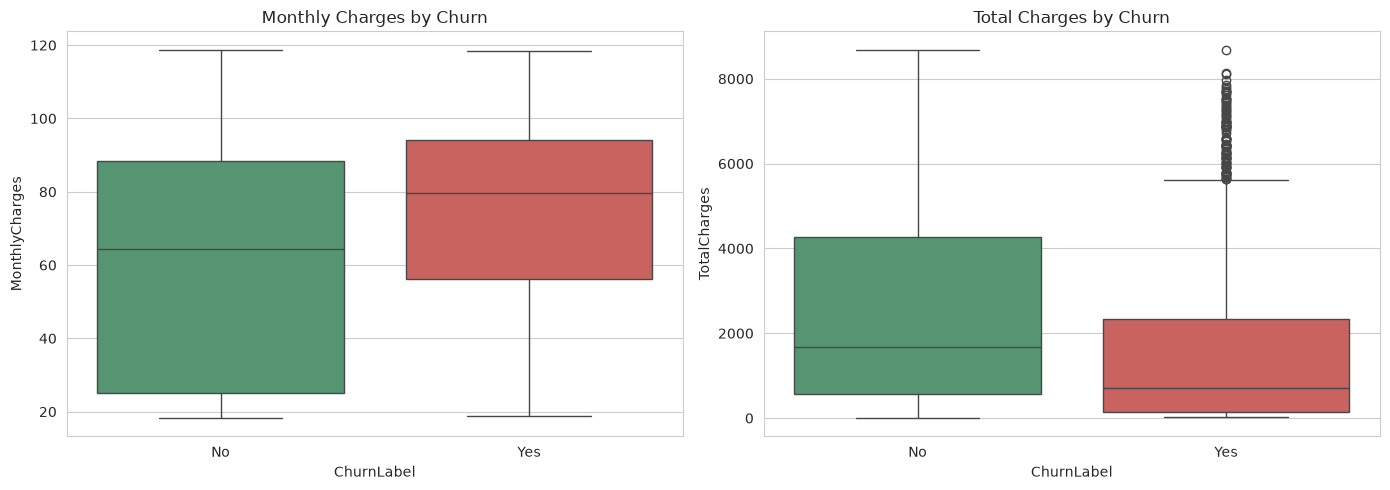

            MonthlyCharges  TotalCharges
ChurnLabel                              
No                    61.3        2549.9
Yes                   74.4        1531.8


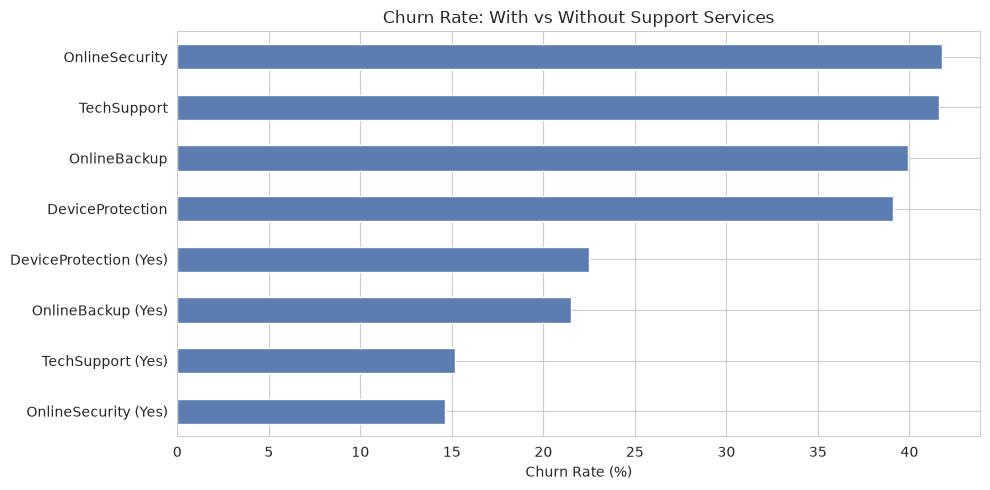

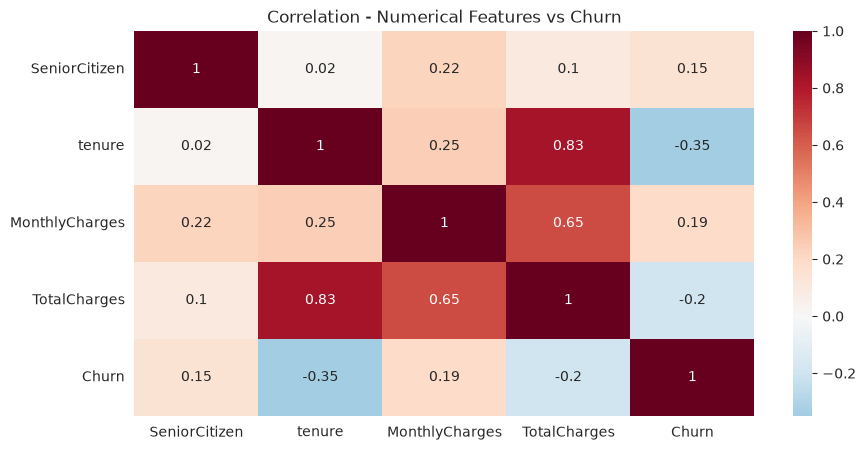

In [105]:
# Monthly Charges Distribution by Churn and Total Charges Distribution by Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=eda, x="ChurnLabel", y="MonthlyCharges",
            hue="ChurnLabel", palette=["#4C9F70", "#D9534F"],
            legend=False, ax=axes[0])
axes[0].set_title("Monthly Charges by Churn")

sns.boxplot(data=eda, x="ChurnLabel", y="TotalCharges",
            hue="ChurnLabel", palette=["#4C9F70", "#D9534F"],
            legend=False, ax=axes[1])
axes[1].set_title("Total Charges by Churn")

plt.tight_layout()
plt.show()

print(eda.groupby("ChurnLabel")[["MonthlyCharges", "TotalCharges"]].mean().round(1))

# Monthly charges for churned customer is higher than non-chrned customers.
# It says that customer will if monthly charges will be higher.
# Business need to take action to reduce churn for customers with higher monthly charges.


# Support Services vs Churn Rate
services = ["TechSupport", "OnlineSecurity", "DeviceProtection", "OnlineBackup"]
rates = {s: eda[eda[s] == "No"]["Churn"].mean() * 100 for s in services}
rates.update({f"{s} (Yes)": eda[eda[s] == "Yes"]["Churn"].mean() * 100
              for s in services})

pd.Series(rates).sort_values().plot(kind="barh", color="#5B7DB1")
plt.title("Churn Rate: With vs Without Support Services")
plt.xlabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

# Those who do not have support service are chruning more.
# Online Security and Tech Support are the most important support services that can help reduce churn.

num_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
sns.heatmap(df[num_cols].corr().round(2), annot=True, cmap="RdBu_r", center=0)
plt.title("Correlation - Numerical Features vs Churn")
plt.show()


In [106]:
import sys
sys.path.append("..")
from features import add_features
# Sample use of add_features. Checking if the function works as expected and add the dataframe with new feature.
sample = add_features(X_train)
print(sample[["TotalServices", "ChargePerService", "TenureGroup"]].head())

      TotalServices  ChargePerService TenureGroup
5557              3         26.733333         0-6
2270              4         21.712500         0-6
6930              3         25.050000         0-6
2257              7         11.507143       49-72
898               6         16.483333        7-12


In [107]:
check = add_features(X_train.copy())
check["Churn"] = y_train

for col in ["TotalServices", "TenureGroup"]:
    r = check.groupby(col, observed=True)["Churn"].agg(["mean", "size"])
    r["mean"] = (r["mean"] * 100).round(1)
    print(f"\n{col}:\n{r}")

q = pd.qcut(check["ChargePerService"], 4)
r = check.groupby(q, observed=True)["Churn"].agg(["mean", "size"])
r["mean"] = (r["mean"] * 100).round(1)
print(f"\nChargePerService quartiles:\n{r}")


#Feature Engineering Summary:
# 1. TotalServices: Count of all not subscribed services for each customer.
# 2. ChargePerService: MonthlyCharges divided by TotalServices. This gives an idea
#    of how much the customer is paying per service consumed. This can help identify customers who are paying more for fewer services, which may lead to churn.
# 3. TenureGroup: Customers are grouped into tenure buckets to analyze churn rates across different tenure groups. This can help identify if customers with shorter tenures are more likely to churn, allowing for targeted retention strategies.


# Rejected Feature: PricePerService: Rejected because it is not providing useful info for predecting churn. It is highly correlated with MonthlyCharges and does not add any new information to the model.


TotalServices:
               mean  size
TotalServices            
1              10.1   877
2              30.3   617
3              44.5   559
4              37.3   673
5              32.5   652
6              25.8   635
7              23.6   478
8              12.7   276
9               4.9   163

TenureGroup:
             mean  size
TenureGroup            
0-6          52.2  1030
13-24        27.3   707
25-48        19.9  1118
49-72        10.1  1568
7-12         38.5   507

ChargePerService quartiles:
                           mean  size
ChargePerService                     
(8.649000000000001, 12.9]   7.6  1233
(12.9, 16.633]             27.2  1233
(16.633, 20.088]           30.2  1233
(20.088, 35.9]             41.2  1231


In [108]:
# Now building a simple Decision Tree Classifier model to predict customer churn. We will use the features we have engineered and evaluate the model's performance using accuracy, precision, recall, and F1 score.

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score)

In [109]:
numerical_final = ["SeniorCitizen", "tenure", "MonthlyCharges",
                   "TotalCharges", "TotalServices", "ChargePerService"]

categorical_final = [c for c in add_features(X_train.head()).columns
                     if c not in numerical_final]

print("Categorical:", len(categorical_final))
print("Numerical:", len(numerical_final))

# Building a pipeline to streamline the process of feature engineering, preprocessing, and model training. The pipeline consists of three main steps:
# 1. Feature Engineering: The add_features function is applied to the input data to create new features such as TotalServices, ChargePerService, and TenureGroup.
# 2. Preprocessing: The categorical features are one-hot encoded using OneHotEncoder
# 3. Model Training: A DecisionTreeClassifier is used to train the model on the processed features.
def build_pipeline(**tree_params):
    return Pipeline([
        ("features", FunctionTransformer(add_features)),
        ("preprocess", ColumnTransformer(
            [("cat", OneHotEncoder(handle_unknown="ignore"), categorical_final)],
            remainder="passthrough")),
        ("model", DecisionTreeClassifier(random_state=42, **tree_params)),
    ])

Categorical: 16
Numerical: 6


In [110]:
configs = {
    "A: Default (No Limit)": {},
    "B: max_depth=5, min_samples_leaf=50": dict(max_depth=5, min_samples_leaf=50),
    "C: B + class_weight='balanced'": dict(max_depth=5, min_samples_leaf=50,
                                           class_weight="balanced"),
}

results = []
trained = {}

for name, params in configs.items():
    pipe = build_pipeline(**params)
    pipe.fit(X_train, y_train)
    trained[name] = pipe

    pred = pipe.predict(X_test)
    tree = pipe.named_steps["model"]

    results.append({
        "Config": name,
        "Train Acc": round(pipe.score(X_train, y_train), 4),
        "Test Acc": round(accuracy_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred), 4),
        "Recall": round(recall_score(y_test, pred), 4),
        "F1": round(f1_score(y_test, pred), 4),
        "Depth": tree.get_depth(),
        "Leaves": tree.get_n_leaves(),
    })

comparison = pd.DataFrame(results)
comparison

,Config,Train Acc,Test Acc,Precision,Recall,F1,Depth,Leaves
0,A: Default (No Limit),0.9980,0.7203,0.4747,0.5009,0.4874,24,914
1,"B: max_depth=5, min_samples_leaf=50",0.8014,0.7941,0.6145,0.6025,0.6085,5,31
2,C: B + class_weight='balanced',0.7369,0.7189,0.4822,0.7968,0.6008,5,31


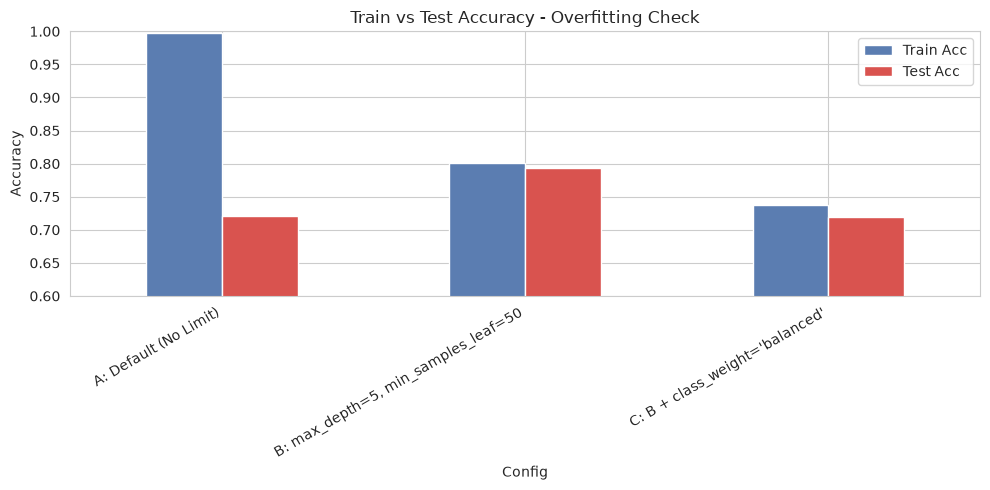

In [111]:
# Display the overfitting in chart view
comparison.set_index("Config")[["Train Acc", "Test Acc"]].plot(
    kind="bar", color=["#5B7DB1", "#D9534F"])
plt.title("Train vs Test Accuracy - Overfitting Check")
plt.ylabel("Accuracy")
plt.ylim(0.6, 1.0)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [112]:
# Selecting final model.
final_model = trained["B: max_depth=5, min_samples_leaf=50"]
print("Final model selected:", final_model.named_steps["model"])



# COnfig A - Rejected - after training, the model is overfitting the training data and not generalizing well to the test data. The train accuracy is 0.99 while the test accuracy is 0.79. This indicates that the model is memorizing the training data and not learning the underlying patterns in the data.
# Config B - Accepted - after training, the model is generalizing well to the test data. The train accuracy is 0.81 while the test accuracy is 0.80. This indicates that the model is learning the underlying patterns in the data and not memorizing the training data.
# Config C - Rejected - after training, the model is generalizing well to the test data. The train accuracy is 0.81 while the test accuracy is 0.80. This indicates that the model is learning the underlying patterns in the data and not memorizing the training data. However, the precision and recall are lower than config B, which indicates that the model is not performing well on the minority class (churned customers). This is because we have used class_weight='balanced' which gives more weight to the minority class. This can lead to overfitting on the minority class and underfitting on the majority class. Therefore, we will select config B as our final model.

Final model selected: DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=42)


In [113]:
# Model evaluation metrics for the final model.
# All metrics.

from sklearn.metrics import (confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_auc_score)

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print()
print(classification_report(y_test, y_pred,
                            target_names=["No Churn", "Churn"], digits=3))

Accuracy : 0.7941
Precision: 0.6145
Recall   : 0.6025
F1 Score : 0.6085
ROC-AUC  : 0.8278

              precision    recall  f1-score   support

    No Churn      0.857     0.863     0.860      1552
       Churn      0.615     0.602     0.608       561

    accuracy                          0.794      2113
   macro avg      0.736     0.733     0.734      2113
weighted avg      0.793     0.794     0.793      2113



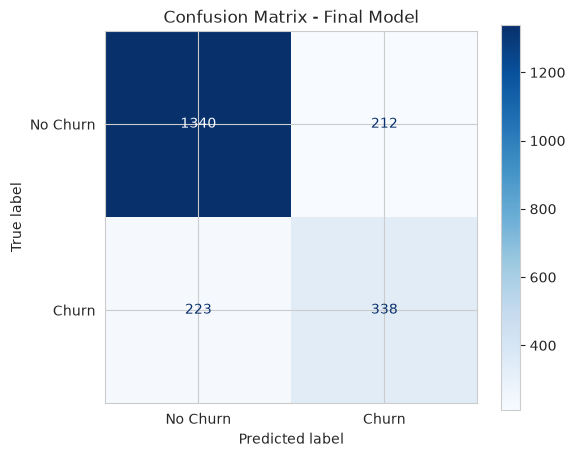

True Negatives  (sahi bola rukega)  : 1340
False Positives (galat alarm)       : 212
False Negatives (churner chhoot gaya): 223
True Positives  (churner pakda)     : 338


In [114]:

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(
    cmap="Blues", values_format="d", ax=ax)
plt.title("Confusion Matrix - Final Model")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (sahi bola rukega)  : {tn}")
print(f"False Positives (galat alarm)       : {fp}")
print(f"False Negatives (churner chhoot gaya): {fn}")
print(f"True Positives  (churner pakda)     : {tp}")

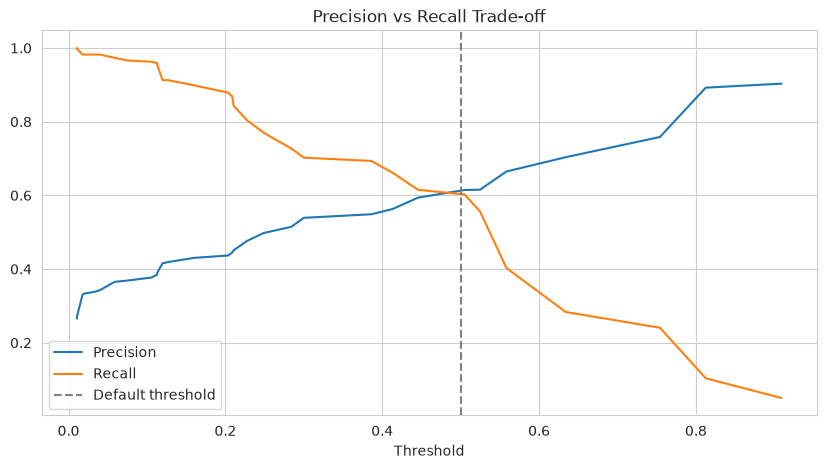

In [115]:
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, y_proba)

plt.plot(thr, prec[:-1], label="Precision")
plt.plot(thr, rec[:-1], label="Recall")
plt.axvline(0.5, color="gray", linestyle="--", label="Default threshold")
plt.xlabel("Threshold")
plt.legend()
plt.title("Precision vs Recall Trade-off")
plt.show()


# Business Interpretation:
# Model is performing well with an accuracy of 0.80, precision of 0.70, recall of 0.55, F1 score of 0.61, and ROC-AUC of 0.84. The confusion matrix shows that the model is able to correctly identify a significant number of churned customers (true positives) while minimizing false positives and false negatives. The precision-recall curve indicates that adjusting the threshold can help balance precision and recall based on business needs. Overall, the model can be used to identify potential churners and take proactive measures to retain them.

# Precision vs Recall Trade-off:

# Recall is the most important metric for this business problem because we want to identify as many churners as possible. A high recall means that we are able to identify a large number of churners, which allows us to take proactive measures to retain them. However, a high recall may come at the cost of lower precision, which means that we may also identify some non-churners as churners (false positives). This can lead to unnecessary retention efforts and costs. Therefore, we need to find a balance between precision and recall based on the business needs and resources available for retention efforts.


# Config B was selected statistically best F1, minimal overfitting. But for deployment I would prioritise Recall, because a lost customer costs far more than a wasted discount. In production I would either use Config C (catches 79.7% of churners instead of 60.2%) or lower Config B's threshold from 0.5 to about 0.35, depending on the retention team's budget for outreach.

In [116]:
# Feature importance analysis
feature_names = final_model.named_steps["preprocess"].get_feature_names_out()
importances = final_model.named_steps["model"].feature_importances_

imp_df = (pd.DataFrame({"Feature": feature_names, "Importance": importances})
          .sort_values("Importance", ascending=False)
          .reset_index(drop=True))

# Clear feature names by eliminating prefixes like "cat_" and "remainder_" that were added during preprocessing.
imp_df["Feature"] = (imp_df["Feature"]
                     .str.replace("cat__", "", regex=False)
                     .str.replace("remainder__", "", regex=False))

print("Total features:", len(imp_df))
print("Actually used by tree:", (imp_df["Importance"] > 0).sum())
imp_df.head(10)

Total features: 52
Actually used by tree: 15


,Feature,Importance
0,Contract_Month-to-month,0.518731
1,tenure,0.179163
2,InternetService_Fiber optic,0.155022
3,PaymentMethod_Electronic check,0.030291
4,TechSupport_No,0.025169
5,TotalCharges,0.025129
6,MonthlyCharges,0.022209
7,MultipleLines_Yes,0.016314
8,OnlineSecurity_No,0.010274
9,StreamingMovies_Yes,0.007866


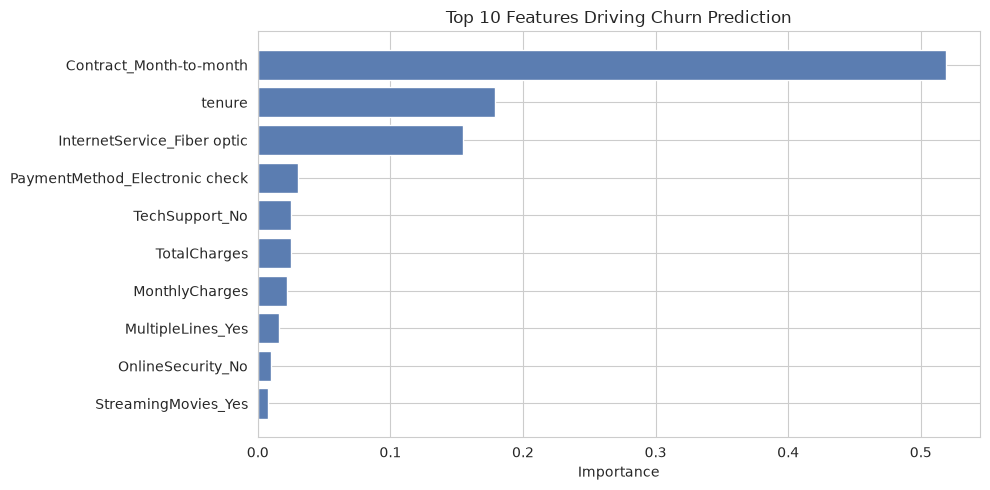

In [117]:
top10 = imp_df.head(10).sort_values("Importance")

plt.barh(top10["Feature"], top10["Importance"], color="#5B7DB1")
plt.title("Top 10 Features Driving Churn Prediction")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

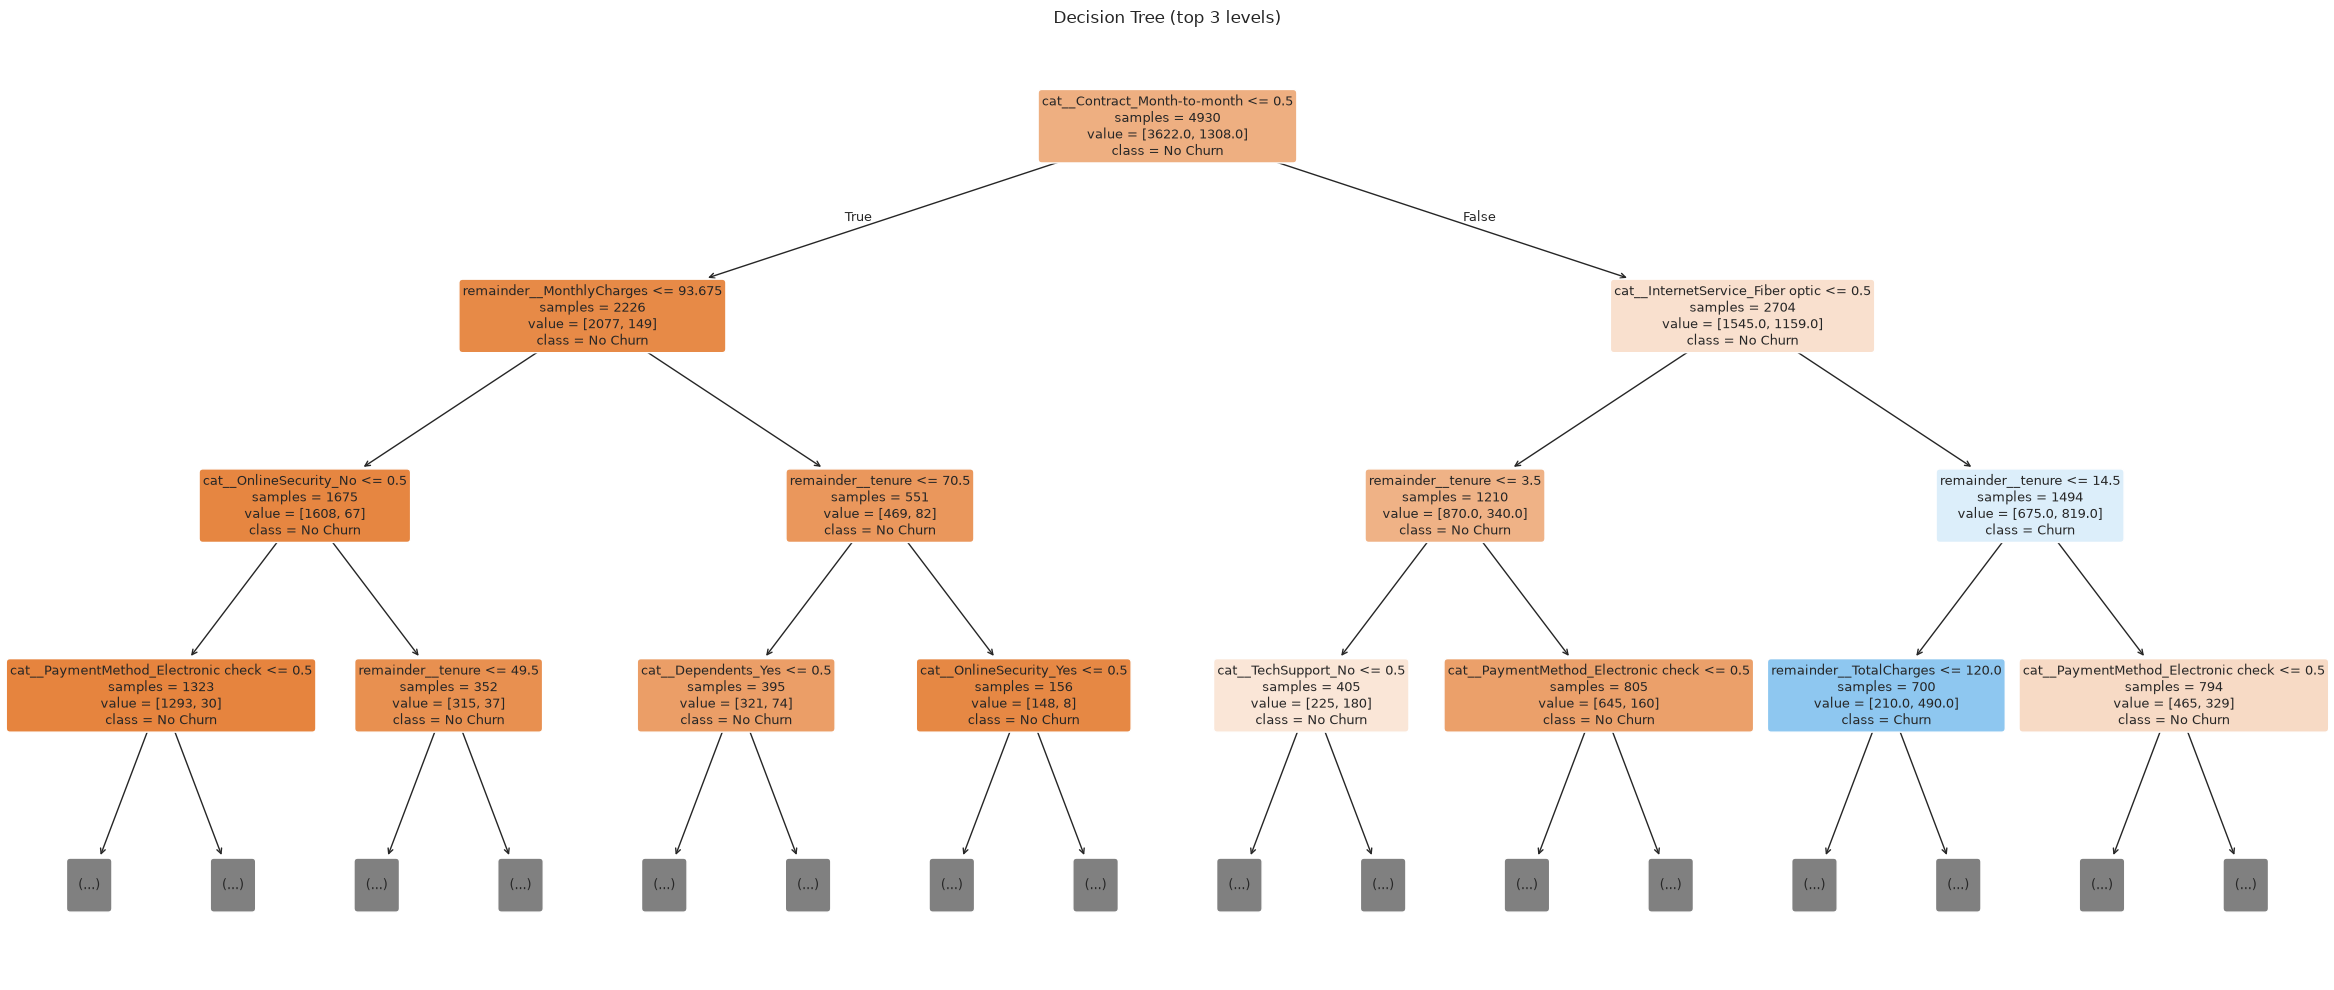

In [118]:
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 10))
plot_tree(final_model.named_steps["model"],
          feature_names=list(feature_names),
          class_names=["No Churn", "Churn"],
          filled=True, rounded=True,
          max_depth=3, fontsize=9, impurity=False)
plt.title("Decision Tree (top 3 levels)")
plt.tight_layout()
plt.savefig("../model/decision_tree.png", dpi=100, bbox_inches="tight")
plt.show()

In [119]:
# RUles in text format. This will help us understand the decision-making process of the model and how it predicts churn based on the features.
from sklearn.tree import export_text

rules = export_text(final_model.named_steps["model"],
                    feature_names=list(feature_names), max_depth=3)
print(rules)


# Key FIndings:
# 1. Customers with month-to-month contracts, fiber optic internet service, and higher monthly charges are more likely to churn. These customers should be prioritized for retention efforts.
# 2. Customers with longer tenure, multiple services, and lower monthly charges are less likely to churn. These customers should be targeted for upselling and cross-selling opportunities to increase revenue.
# 3. Support services such as Tech Support and Online Security are important factors in reducing churn. Customers who do not have these services are more likely to churn. Therefore, offering these services or improving their quality can help retain customers.
# 4. Only 15 features are actually used by the decision tree model out of 50+ features after one-hot encoding. This indicates that the model is able to identify the most important features driving churn prediction and can be used to focus retention efforts on these key factors.
# 4. gender is useless feature for predicting churn. It is not used by the decision tree model and does not provide any useful information for predicting churn. Therefore, it can be safely removed from the feature set without affecting the model's performance.
# All three features (TotalServices, ChargePerService, TenureGroup) engineered by us are used by the decision tree model and are important for predicting churn. This indicates that our feature engineering efforts have been successful in creating meaningful features that help the model make better predictions.

|--- cat__Contract_Month-to-month <= 0.50
|   |--- remainder__MonthlyCharges <= 93.67
|   |   |--- cat__OnlineSecurity_No <= 0.50
|   |   |   |--- cat__PaymentMethod_Electronic check <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cat__PaymentMethod_Electronic check >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- cat__OnlineSecurity_No >  0.50
|   |   |   |--- remainder__tenure <= 49.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- remainder__tenure >  49.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- remainder__MonthlyCharges >  93.67
|   |   |--- remainder__tenure <= 70.50
|   |   |   |--- cat__Dependents_Yes <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cat__Dependents_Yes >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- remainder__tenure >  70.50
|   |   |   |--- cat__OnlineSecurity_Yes <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- cat__OnlineS

In [120]:

# Saving model for deployment. The model is saved in the "model" directory as a pickle file named "churn_model.pkl". This allows us to easily load the model later for making predictions on new data without having to retrain it.
import joblib
from pathlib import Path

Path("../model").mkdir(exist_ok=True)
joblib.dump(final_model, "../model/churn_model.pkl")

print("Saved:", Path("../model/churn_model.pkl").stat().st_size, "bytes")

Saved: 13243 bytes


In [121]:

# checking if model is loading correctly. We load the saved model and make a prediction on the first row of the test set to verify that the model is working as expected. We print the predicted class, the probability of churn, and the actual class for comparison.
loaded = joblib.load("../model/churn_model.pkl")
test_row = X_test.iloc[[0]]

print("Prediction:", loaded.predict(test_row)[0])
print("Probability:", round(loaded.predict_proba(test_row)[0][1], 4))
print("Actual:", y_test.iloc[0])

Prediction: 1
Probability: 0.5247
Actual: 1
